# Segunda fase

In [1]:
# Importing classes of the project

# Reload classes in memory every time this code block is executed
%load_ext autoreload
%autoreload 2

import os
from collections import Counter
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils import compute_class_weight
from sklearn.metrics import confusion_matrix

from data_analysis.analizer import DataAnalizer

# model evaluator
from model_building.ModelEvaluator import ModelEvaluator
# KNN
from model_building.KNN import KNN
# Supervised Learning
from model_building.DecisionTree import DecisionTree
#from model_building.SVM import SupportVectorMachine  # removido por demorar muito a treinar
from model_building.LinearModels import LinearModels

# Boosting and Bagging
from model_building.RandomForest import RandomForest
from model_building.AdaBoost import AdaBoost
# Deep Learning
from model_building.BaseNeuralNetwork import BaseNeuralNetwork
from model_building.NeuralNetworkTrainer import NeuralNetworkTrainer
# Clustering
from model_building.GDBSCANMixed import GDBSCANMixed
from model_building.KPrototypes import KPrototypesModel

In [2]:
# ==========================================
#  Setup do diretório de output dos modelos
# ==========================================
model_output_dir = "../out/models/"
os.makedirs(model_output_dir, exist_ok=True)


# ==================
#  Setup do dataset
# ==================

df = pd.read_csv("../out/dataset.csv")

# a grande maioria das entradas têm valores nulos em "congestion_surcharge"
del df["congestion_surcharge"]

# dados continuos (não é possivel normalizar estes dados)
del df["pickup_time_in_seconds"]
del df["dropoff_time_in_seconds"]

# Remove all rows with any missing values (NaN)
df= df.dropna()

# =============================================
# 1. REGRESSION DATASET (continuous target)
# =============================================

# Separate features and target
X_reg = df.drop(columns=['fare_amount'])
y_reg = df['fare_amount']

# Scale only the features (not target)
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Create scaled DataFrame for regression
df_regression = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)
df_regression['fare_amount'] = y_reg.values  # Add unscaled target

analizer_reg = DataAnalizer(df_regression, "fare_amount", test_size=0.02)


# =============================================
# 2. CLASSIFICATION DATASET (categorical target)
# =============================================

# Create fare classes
bins = [-np.inf, 10, 30, 60, np.inf]
labels = [1, 2, 3, 4]

# Create classification target
df_classification = df.copy()
df_classification['fare_class'] = pd.cut(
    df['fare_amount'],
    bins=bins,
    labels=labels
)

# Separate features and target
X_clf = df_classification.drop(columns=['fare_amount', 'fare_class'])
y_clf = df_classification['fare_class']

# Scale features using SAME scaler (important for consistency)
X_clf_scaled = scaler.transform(X_clf)  # Use existing scaler

# Create scaled DataFrame for classification
df_classification_scaled = pd.DataFrame(X_clf_scaled, columns=X_clf.columns)
df_classification_scaled['fare_class'] = y_clf.values  # Add target

analizer_clf = DataAnalizer(df_classification_scaled, "fare_class", test_size=0.2)

# =============================================
# Verification
# =============================================
print("Regression dataset:")
print(df_regression.head())

print("\nClassification dataset:")
print(df_classification_scaled.head())

print(df_classification['fare_class'].value_counts(normalize=True))


Data divided successfully.
Data divided successfully.
Regression dataset:
   trip_distance  tip_amount  tolls_amount     extra  passenger_count  \
0      -0.666634   -0.760919     -0.229742 -0.463238        -0.470065   
1      -0.404075    0.619532     -0.229742 -0.463238        -0.470065   
2      -0.455557   -0.174228     -0.229742 -0.463238        -0.470065   
3      -0.149237   -0.760919     -0.229742 -0.463238        -0.470065   
4       1.665513    0.964644     -0.229742 -0.463238        -0.470065   

   pickup_hour  pickup_day_of_week  pickup_day_of_month  pickup_month  \
0    -2.316139           -1.018927            -1.674574     -1.532716   
1    -2.316139           -1.018927            -1.674574     -1.532716   
2    -2.316139           -1.018927            -1.674574     -1.532716   
3    -2.316139           -1.018927            -1.674574     -1.532716   
4    -2.316139           -1.018927            -1.674574     -1.532716   

   dropoff_hour  dropoff_day_of_week  dropoff_da

# KNN

O KNN (K-Nearest Neighbors, ou K-Vizinhos Mais Próximos) é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele se baseia no princípio de que objetos semelhantes estão próximos no espaço de características.

**Funcionamento:**


Calcula a distância (ex.: Euclidiana, Manhattan) entre o novo dado e todos os pontos no conjunto de treinamento.

Seleciona os K vizinhos mais próximos.

Classifica (moda das classes dos vizinhos) ou prediz (média dos valores dos vizinhos).



In [ ]:
# Regressão com KNN

k_values_knn_reg = [1, 3, 5, 10, 15]
best_cv_rmse_knn_reg = float('inf')
best_k_knn_reg = None
all_cv_results_knn_reg = {} # Para armazenar resultados de CV de cada k

for k_val in k_values_knn_reg:
    print(f"\nAvaliando KNN Regressor com k = {k_val} usando Validação Cruzada nos dados de treino...")

    # 1. Cria o modelo KNN para regressão
    current_knn_model = KNN(k=k_val, task='regression', verbose=False)
    
    # 2. Instanciar o ModelEvaluator para avaliação com cross-validation
    # O modelo (current_knn_model) será treinado dentro dos folds pelo ModelEvaluator
    evaluator_cv = ModelEvaluator(
        model=current_knn_model, # O ModelEvaluator clonará e treinará este modelo em cada fold
        task_type="regression",
        metrics=["rmse", "mae", "r2"],
        cv_method='kfold',
        cv_folds=5,
    )

    try:
        # 3. Avaliar usando dados de TREINO com Validação Cruzada
        # cv_strategy=True garante que o ModelEvaluator usará 'kfold' com 5 folds
        # nos dados fornecidos (analizer_reg.data_train, analizer_reg.labels_train)
        cv_results = evaluator_cv.evaluate(
            X=analizer_reg.data_train,
            y=analizer_reg.labels_train,
            cv_strategy=True
        )
        all_cv_results_knn_reg[k_val] = cv_results

        print(f"Resultados da Validação Cruzada (CV) para k={k_val}:")
        for metric, value in cv_results.items():
            if isinstance(value, (int, float, np.number)): # np.number para cobrir tipos numéricos do numpy
                print(f"  {metric}: {value:.4f}")
            # else: # Para 'predictions' ou 'probabilities' se return_predictions=True
            #     print(f"  {metric}: {value}")

        # 4. Lógica para selecionar o melhor k baseado no RMSE médio da CV
        current_cv_rmse_mean = cv_results.get('rmse_mean')
        if current_cv_rmse_mean is not None and current_cv_rmse_mean < best_cv_rmse_knn_reg:
            best_cv_rmse_knn_reg = current_cv_rmse_mean
            best_k_knn_reg = k_val
            print(f"  -> Novo melhor k encontrado por CV: {best_k_knn_reg} (rmse_mean={best_cv_rmse_knn_reg:.4f})")

    except Exception as e:
        print(f"Ocorreu um erro durante a avaliação por CV para k={k_val}: {e}")

# --- Treinar e Avaliar o Melhor Modelo de Regressão no Conjunto de Teste e Salvar ---
if best_k_knn_reg is not None:
    print("-" * 30)
    print(f"Melhor k encontrado após Validação Cruzada: {best_k_knn_reg} (CV rmse_mean: {best_cv_rmse_knn_reg:.4f})")

    # 1. Treinar o modelo final com o melhor k em TODOS os dados de TREINO
    print(f"Re-treinando o modelo KNN com k={best_k_knn_reg} no conjunto de treino completo...")
    final_best_knn_model_reg = KNN(k=best_k_knn_reg, task='regression', verbose=False)
        

    final_best_knn_model_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

    # 2. Avaliar o modelo final no conjunto de TESTE (sem CV)
    print("Avaliando o modelo final no conjunto de teste...")
    evaluator_test = ModelEvaluator(
        model=final_best_knn_model_reg, # Modelo já treinado
        task_type="regression",
        metrics=["rmse", "mae", "r2"],
        cv_method=None # Garantir que não haverá CV aqui
    )
    # Por padrão, cv_strategy=None e cv_method=None no evaluator_test
    # fará uma avaliação direta sem CV.
    test_results_knn_reg = evaluator_test.evaluate(
        X=analizer_reg.data_test,
        y=analizer_reg.labels_test
    )

    print("Resultados da Avaliação no Conjunto de Teste:")
    for metric, value in test_results_knn_reg.items():
        if isinstance(value, (int, float, np.number)):
            print(f"  {metric}: {value:.4f}")

    # 3. Salvar o melhor modelo de REGRESSÃO
    test_rmse = test_results_knn_reg.get('rmse', float('nan')) # Pegar o RMSE do teste para o nome do arquivo
    model_filename = f"knnRegressor_best_k{best_k_knn_reg}_cvRmse{best_cv_rmse_knn_reg:.2f}_testRmse{test_rmse:.2f}.pkl"
    model_full_path = model_output_dir / model_filename

    print(f"Salvando o melhor modelo de regressão KNN em: {model_full_path.resolve()}")
    final_best_knn_model_reg.serialize(model_output_dir+"KNN-Regressor.pkl")
    print(f"Melhor modelo de regressão KNN salvo com sucesso!")
    print("-" * 30)
else:
    print("-" * 30)
    print("Nenhum modelo de regressão KNN foi avaliado e selecionado com sucesso após Validação Cruzada.")
    print("-" * 30)

Data divided successfully.
Training KNN Regression for k = 5
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=5: RMSE = 4.43
Training KNN Regression for k = 10
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=10: RMSE = 4.63
Training KNN Regression for k = 15
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=15: RMSE = 4.80
Training KNN Regression for k = 20
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=20: RMSE = 4.90
Training KNN Regression for k = 25
KD-Tree built with 131068 nodes, dimensions=19
Processed 1000/1688
Prediction complete
k=25: RMSE = 4.99

Final Regression Results:
{5: np.float64(4.427841938487359), 10: np.float64(4.626283588500842), 15: np.float64(4.79722290519828), 20: np.float64(4.8972478527938845), 25: np.float64(4.990911051727522)}


In [ ]:
# Classificação

k_values_knn_clf = [1, 3, 5, 10, 15]
best_cv_accuracy_knn_clf = -float('inf')
best_k_knn_clf = None
all_cv_results_knn_clf = {} # To store CV results for each k

for k_val in k_values_knn_clf:
    print(f"\nAvaliando KNN Classifier com k = {k_val} usando Validação Cruzada nos dados de treino...")

    current_knn_model = KNN(k=k_val, task='classification', verbose=False)
    
    # 2. Instanciar o ModelEvaluator para avaliação com cross-validation
    evaluator_cv = ModelEvaluator(
        model=current_knn_model,
        task_type="classification",
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro"], # Classification metrics
        cv_method='kfold',
        cv_folds=5,
    )

    try:
        # 3. Avaliar usando dados de TREINO com Validação Cruzada
        cv_results = evaluator_cv.evaluate(
            X=analizer_clf.data,
            y=analizer_clf.labels_train,
            cv_strategy=True
        )
        all_cv_results_knn_clf[k_val] = cv_results

        print(f"Resultados da Validação Cruzada (CV) para k={k_val}:")
        for metric, value in cv_results.items():
            if isinstance(value, (int, float, np.number)):
                print(f"  {metric}: {value:.4f}")
            # else: # For 'confusion_matrix' or other non-scalar results if returned by CV part
            #     print(f"  {metric}: {value}")

        # 4. Lógica para selecionar o melhor k baseado na Acurácia média da CV
        current_cv_accuracy_mean = cv_results.get('accuracy_mean')
        if current_cv_accuracy_mean is not None and current_cv_accuracy_mean > best_cv_accuracy_knn_clf:
            best_cv_accuracy_knn_clf = current_cv_accuracy_mean
            best_k_knn_clf = k_val
            print(f"  -> Novo melhor k encontrado por CV: {best_k_knn_clf} (accuracy_mean={best_cv_accuracy_knn_clf:.4f})")

    except Exception as e:
        print(f"Ocorreu um erro durante a avaliação por CV para k={k_val}: {e}")

# --- Treinar e Avaliar o Melhor Modelo de Classificação no Conjunto de Teste e Salvar ---
if best_k_knn_clf is not None:
    print("-" * 30)
    print(f"Melhor k encontrado após Validação Cruzada: {best_k_knn_clf} (CV accuracy_mean: {best_cv_accuracy_knn_clf:.4f})")

    # 1. Treinar o modelo final com o melhor k em TODOS os dados de TREINO
    print(f"Re-treinando o modelo KNN com k={best_k_knn_clf} no conjunto de treino completo...")
    final_best_knn_model_clf = KNN(k=best_k_knn_clf, task='classification', verbose=False)
    final_best_knn_model_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # 2. Avaliar o modelo final no conjunto de TESTE (sem CV)
    print("Avaliando o modelo final no conjunto de teste...")
    evaluator_test = ModelEvaluator(
        model=final_best_knn_model_clf, # Modelo já treinado
        task_type="classification",
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro", "confusion_matrix"], # Include CM for test
        cv_method=None 
    )
    test_results_knn_clf = evaluator_test.evaluate(
        X=analizer_clf.data_test,
        y=analizer_clf.labels_test
    )

    print("Resultados da Avaliação no Conjunto de Teste:")
    for metric, value in test_results_knn_clf.items():
        if isinstance(value, (int, float, np.number)):
            print(f"  {metric}: {value:.4f}")
        elif metric == "confusion_matrix": # Specific handling for confusion matrix if you want to print it nicely
             print(f"  {metric}:")
             for row in value:
                 print(f"    {row}")

    # 3. Salvar o melhor modelo de CLASSIFICAÇÃO
    test_accuracy = test_results_knn_clf.get('accuracy', 0.0) 
    model_filename = f"knnClassifier_best_k{best_k_knn_clf}_cvAcc{best_cv_accuracy_knn_clf:.2f}_testAcc{test_accuracy:.2f}.pkl"
    # Ensure model_output_dir is a Path object for this to work seamlessly
    model_full_path = model_output_dir / model_filename

    print(f"Salvando o melhor modelo de classificação KNN em: {model_full_path.resolve()}")
    # Use the generated model_full_path for saving
    final_best_knn_model_clf.serialize(model_output_dir+"KNN-Classifier.pkl")
    print(f"Melhor modelo de classificação KNN salvo com sucesso!")
    print("-" * 30)
else:
    print("-" * 30)
    print("Nenhum modelo de classificação KNN foi avaliado e selecionado com sucesso após Validação Cruzada.")
    print("-" * 30)

Data divided successfully.
Training KNN Classification for k = 5
KD-Tree built with 131008 nodes, dimensions=19
Processed 1000/16876
Processed 2000/16876
Processed 3000/16876
Processed 4000/16876
Processed 5000/16876
Processed 6000/16876
Processed 7000/16876
Processed 8000/16876
Processed 9000/16876
Processed 10000/16876
Processed 11000/16876
Processed 12000/16876
Processed 13000/16876
Processed 14000/16876
Processed 15000/16876
Processed 16000/16876
Prediction complete
k=5: Precision = 0.7533
Training KNN Classification for k = 10
KD-Tree built with 131008 nodes, dimensions=19
Processed 1000/16876
Processed 2000/16876
Processed 3000/16876
Processed 4000/16876
Processed 5000/16876
Processed 6000/16876
Processed 7000/16876
Processed 8000/16876
Processed 9000/16876
Processed 10000/16876
Processed 11000/16876
Processed 12000/16876
Processed 13000/16876
Processed 14000/16876
Processed 15000/16876
Processed 16000/16876
Prediction complete
k=10: Precision = 0.7489
Training KNN Classification

# Árvore de decisão

A Árvore de Decisão é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele divide os dados em subconjuntos com base em regras de decisão hierárquicas, formando uma estrutura semelhante a uma árvore.

**Funcionamento:**

Seleciona o melhor atributo para dividir os dados (usando critérios como Gini, Entropia ou Erro quadrático).

Divide o dataset recursivamente, criando nós de decisão até atingir uma condição de parada (ex.: profundidade máxima ou número mínimo de amostras por folha).

Classifica ou prediz com base na folha (nó final) em que o dado cai.

In [3]:
# Classification with Decision Tree
best_f1_macro = -float('inf') # Inicializa com um valor muito baixo para encontrar o máximo
best_model_clf = None
best_depth_clf = None
all_clf_results = {} # Opcional: para armazenar todos os resultados se necessário

print("--- Classificação com Decision Tree ---")

for depth in [None, 2, 5, 10, 20]:
    print(f"\nTraining Decision Tree Classification for max_depth = {depth}")
    dt_clf = DecisionTree(
        problem_type='classification',
        max_depth=depth,
        class_weight='balanced',
        random_state=42 # Adicionado para reprodutibilidade se a árvore tiver elementos aleatórios
    )

    # evaluate the model
    evaluator = ModelEvaluator(
        model=dt_clf,
        task_type="multiclass",
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro", "log_loss"],
        cv_method='stratifiedkfold',
        cv_folds=5,
        random_state=42 # Adicionado para reprodutibilidade na CV
    )

    print(f"max_depth={depth}")
    try:
        results_clf = evaluator.evaluate(analizer_clf.data_train, analizer_clf.labels_train)
        all_clf_results[depth] = results_clf # Armazena os resultados

        print("Resultados CV:")
        for metric, value in results_clf.items():
             # Verifica se é um valor numérico para formatar
            if isinstance(value, (int, float)):
                 print(f"{metric}: {value:.4f}")
            else:
                 print(f"{metric}: {value}")


        # --- Lógica para selecionar o melhor modelo ---
        # Usamos a média do f1_macro da validação cruzada para comparar
        current_f1_macro_mean = results_clf.get('f1_macro_mean') # Assume que ModelEvaluator retorna metric_mean

        if current_f1_macro_mean is not None and current_f1_macro_mean > best_f1_macro:
            best_f1_macro = current_f1_macro_mean
            best_model_clf = dt_clf # Guarda a instância do modelo treinado no último fold ou a regra da classe ModelEvaluator
            best_depth_clf = depth
            print(f"-> Novo melhor modelo encontrado com max_depth={depth} (f1_macro_mean={best_f1_macro:.4f})")

    except Exception as e:
        print(f"An error occurred during evaluation for max_depth={depth}: {e}")

if best_model_clf is not None:
    print("-" * 30)
    print("Saving best model...")
    best_model_clf.serialize(model_output_dir+"decisionTreeClassfier.pkl")
    print("-" * 30)

--- Classificação com Decision Tree ---

Training Decision Tree Classification for max_depth = None
max_depth=None
Resultados CV:
accuracy_mean: 0.8880
precision_macro_mean: 0.8625
recall_macro_mean: 0.8503
f1_macro_mean: 0.8561
log_loss_mean: 4.0379
accuracy_std: 0.0025
precision_macro_std: 0.0101
recall_macro_std: 0.0090
f1_macro_std: 0.0085
log_loss_std: 0.0889
-> Novo melhor modelo encontrado com max_depth=None (f1_macro_mean=0.8561)

Training Decision Tree Classification for max_depth = 2
max_depth=2
Resultados CV:
accuracy_mean: 0.6277
precision_macro_mean: 0.4783
recall_macro_mean: 0.6669
f1_macro_mean: 0.5545
log_loss_mean: 0.7730
accuracy_std: 0.0003
precision_macro_std: 0.0078
recall_macro_std: 0.0076
f1_macro_std: 0.0068
log_loss_std: 0.0014

Training Decision Tree Classification for max_depth = 5
max_depth=5
Resultados CV:
accuracy_mean: 0.8598
precision_macro_mean: 0.7698
recall_macro_mean: 0.8868
f1_macro_mean: 0.8170
log_loss_mean: 0.3490
accuracy_std: 0.0038
precision_m

In [4]:
best_rmse = float('inf') # Initialize with a very high value to find the minimum
best_model_reg = None
best_depth_reg = None
all_reg_results = {} # Opcional: para armazenar todos os resultados se necessário

print("\n" + "=" * 40) # Separator
print("--- Regressão com Decision Tree ---")

for depth in [None, 2, 5, 10, 20]:
    print(f"\nTraining Decision Tree Regression for max_depth = {depth}")
    dt_reg = DecisionTree(problem_type='regression', max_depth=depth, random_state=42)

    # Evaluate the model using ModelEvaluator for regression with multiple metrics
    evaluator_reg = ModelEvaluator(
        model=dt_reg,
        task_type="regression",
        metrics=['rmse', 'mse', 'mae', 'r2'],  # Evaluate using RMSE, MSE, MAE, and R-squared
        cv_method='kfold',
        cv_folds=5,
        random_state=42
    )

    print(f"max_depth={depth}")
    try:
        results_reg = evaluator_reg.evaluate(analizer_reg.data_train, analizer_reg.labels_train)
        all_reg_results[depth] = results_reg # Armazena os resultados

        print("Resultados CV:")
        # Extract and print mean/std for key metrics for the current depth
        current_rmse_mean = results_reg.get('rmse_mean')
        current_mse_mean = results_reg.get('mse_mean')
        current_mae_mean = results_reg.get('mae_mean')
        current_r2_mean = results_reg.get('r2_mean')

        if current_rmse_mean is not None: print(f"rmse_mean: {current_rmse_mean:.4f}")
        if results_reg.get('rmse_std') is not None: print(f"rmse_std: {results_reg['rmse_std']:.4f}")
        if current_mse_mean is not None: print(f"mse_mean: {current_mse_mean:.4f}")
        if results_reg.get('mse_std') is not None: print(f"mse_std: {results_reg['mse_std']:.4f}")
        if current_mae_mean is not None: print(f"mae_mean: {current_mae_mean:.4f}")
        if results_reg.get('mae_std') is not None: print(f"mae_std: {results_reg['mae_std']:.4f}")
        if current_r2_mean is not None: print(f"r2_mean: {current_r2_mean:.4f}")
        if results_reg.get('r2_std') is not None: print(f"r2_std: {results_reg['r2_std']:.4f}")


        # --- Lógica para selecionar o melhor modelo de REGRESSÃO ---
        # Usamos a média do rmse da validação cruzada para comparar (menor é melhor)
        # current_rmse_mean is already extracted above

        if current_rmse_mean is not None and current_rmse_mean < best_rmse:
            best_rmse = current_rmse_mean
            best_model_reg = dt_reg # Guarda a instância do modelo configurado para esta profundidade
            best_depth_reg = depth
            print(f"-> Novo melhor modelo REGRESSÃO encontrado com max_depth={depth} (rmse_mean={best_rmse:.4f})")

    except Exception as e:
        print(f"An error occurred during regression evaluation for max_depth={depth}: {e}")

# --- Salva o melhor modelo de REGRESSÃO ---
if best_model_reg is not None:
    print("-" * 30)
    print("Saving best regression model...")
     # Similar note as classification: re-train on full data if needed before saving
    best_model_reg.serialize(model_output_dir+"decisionTreeRegressor.pkl")
    print(f"Best regression model (max_depth={best_depth_reg}, rmse_mean={best_rmse:.4f}) saved to {model_output_dir}decisionTreeRegressor.pkl")
    print("-" * 30)
else:
     print("-" * 30)
     print("No regression model was successfully evaluated.")
     print("-" * 30)


--- Regressão com Decision Tree ---

Training Decision Tree Regression for max_depth = None
max_depth=None
Resultados CV:
rmse_mean: 5.4510
rmse_std: 1.6482
mse_mean: 32.4301
mse_std: 21.6619
mae_mean: 1.6929
mae_std: 0.0452
r2_mean: 0.8064
r2_std: 0.0861
-> Novo melhor modelo REGRESSÃO encontrado com max_depth=None (rmse_mean=5.4510)

Training Decision Tree Regression for max_depth = 2
max_depth=2
Resultados CV:
rmse_mean: 7.2571
rmse_std: 1.5701
mse_mean: 55.1300
mse_std: 26.4347
mae_mean: 3.4721
mae_std: 0.4183
r2_mean: 0.6623
r2_std: 0.0894

Training Decision Tree Regression for max_depth = 5
max_depth=5
Resultados CV:
rmse_mean: 6.7504
rmse_std: 2.0708
mse_mean: 49.8566
mse_std: 26.4153
mae_mean: 2.0266
mae_std: 0.0646
r2_mean: 0.6866
r2_std: 0.1582

Training Decision Tree Regression for max_depth = 10
max_depth=10
Resultados CV:
rmse_mean: 4.7395
rmse_std: 1.8454
mse_mean: 25.8687
mse_std: 22.5014
mae_mean: 1.5451
mae_std: 0.0345
r2_mean: 0.8505
r2_std: 0.0947
-> Novo melhor mod

# Linear Models

Nesta secção trabalhamos com modelos lineares como Regressão linear e suas variantes para fazer regressão no nosso conjunto de dados e regressão logística para fazer classificação.

In [6]:
best_r2_linear = -float('inf')
best_linear_models_instance = None
best_params_linear_reg = None
all_linear_reg_results = {}

numerical_features = [
    'trip_distance', 'tip_amount', 'tolls_amount', 'extra', 'passenger_count',
    'pickup_hour', 'pickup_day_of_week', 'pickup_day_of_month', 'pickup_month',
    'dropoff_hour', 'dropoff_day_of_week', 'dropoff_day_of_month', 'dropoff_month',
    'mta_tax'
]

categorical_features = [
    'vendorid', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type'
]

linear_regression_models = ['linear', 'ridge', 'lasso', 'elasticnet']

for model_name in linear_regression_models:
    print(f"\n--- Treinando Regressão {model_name.upper()} com GridSearchCV ---")

    linear_reg_model = LinearModels(
        problem_type='regression',
        model_name=model_name,
        grid_search=True,
        verbose=1,
        scoring='r2',
        random_state=42
    )

    current_r2_mean_for_comparison = -float('inf')
    current_best_params_for_comparison = {}

    try:
        linear_reg_model.fit(analizer_reg.data_train, analizer_reg.labels_train)

        if linear_reg_model.best_model is not None and linear_reg_model.cv_results is not None:
            results_cv_reg = linear_reg_model.cv_results

            if 'mean_test_score' in results_cv_reg and len(results_cv_reg['mean_test_score']) > 0:
                best_index_reg = np.argmax(results_cv_reg['mean_test_score'])
                current_r2_mean_for_comparison = results_cv_reg['mean_test_score'][best_index_reg]
                current_best_params_for_comparison = results_cv_reg['params'][best_index_reg]

                all_linear_reg_results[model_name] = {
                    'best_r2_mean_cv': current_r2_mean_for_comparison,
                    'best_params': current_best_params_for_comparison,
                    'all_cv_results': results_cv_reg
                }

                print(f"\nResultados CV para {model_name.upper()} (Melhor Combinação):")
                print(f"R^2_mean: {current_r2_mean_for_comparison:.4f}")
                print(f"Melhores Parâmetros: {current_best_params_for_comparison}")

                evaluation_results = linear_reg_model.evaluate(analizer_reg.data_test, analizer_reg.labels_test)
                print(f"MSE no Teste: {evaluation_results.get('mean_squared_error', np.nan):.4f}")
                print(f"R^2 no Teste: {evaluation_results.get('r2_score', np.nan):.4f}")

            else:
                print(f"AVISO: 'mean_test_score' não disponível ou vazio nos resultados de CV para {model_name.upper()}.")
                evaluation_results = linear_reg_model.evaluate(analizer_reg.data_test, analizer_reg.labels_test)
                current_r2_mean_for_comparison = evaluation_results.get('r2_score', -float('inf'))
                current_best_params_for_comparison = {}
                print(f"R^2 no Teste (fallback): {current_r2_mean_for_comparison:.4f}")

                all_linear_reg_results[model_name] = {
                    'best_r2_mean_test_fallback': current_r2_mean_for_comparison,
                    'best_params': current_best_params_for_comparison,
                    'all_cv_results': {}
                }
        else:
            print(f"AVISO: Modelo {model_name.upper()} não foi treinado com sucesso (best_model ou cv_results são None após fit).")
            current_r2_mean_for_comparison = -float('inf')

    except Exception as e:
        print(f"ERRO CRÍTICO no loop para o modelo {model_name.upper()}: {e}")
        current_r2_mean_for_comparison = -float('inf')

    if current_r2_mean_for_comparison > best_r2_linear:
        best_r2_linear = current_r2_mean_for_comparison
        if linear_reg_model.best_model is not None:
            best_linear_models_instance = linear_reg_model
            best_params_linear_reg = current_best_params_for_comparison
            print(f"-> Novo melhor modelo linear global: {model_name.upper()} (R^2={best_r2_linear:.4f})")
        else:
            print(f"AVISO: Modelo {model_name.upper()} tinha melhor R^2 mas não foi salvo como 'best_model' devido a falha no treino.")

if best_linear_models_instance is not None:
    print("-" * 30)
    print("Salvando o melhor modelo linear de regressão...")
    best_linear_models_instance.serialize(os.path.join(model_output_dir, "bestLinearRegressor.pkl"))
    print("Modelo linear de regressão salvo com sucesso!")
    print(f"Melhor modelo linear geral (R^2 no CV/Teste): {best_r2_linear:.4f} com parâmetros: {best_params_linear_reg}")
    print("-" * 30)
else:
    print("Nenhum modelo linear de regressão foi treinado ou selecionado com sucesso.")


--- Treinando Regressão LINEAR com GridSearchCV ---
Iniciando GridSearchCV para LINEAR...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
GridSearchCV finalizado para LINEAR. Melhores parâmetros: {}

Resultados CV para LINEAR (Melhor Combinação):
R^2_mean: 0.5408
Melhores Parâmetros: {}
MSE no Teste: 13.3186
R^2 no Teste: 0.9010
-> Novo melhor modelo linear global: LINEAR (R^2=0.5408)

--- Treinando Regressão RIDGE com GridSearchCV ---
Iniciando GridSearchCV para RIDGE...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
GridSearchCV finalizado para RIDGE. Melhores parâmetros: {}

Resultados CV para RIDGE (Melhor Combinação):
R^2_mean: 0.7592
Melhores Parâmetros: {}
MSE no Teste: 13.3186
R^2 no Teste: 0.9010
-> Novo melhor modelo linear global: RIDGE (R^2=0.7592)

--- Treinando Regressão LASSO com GridSearchCV ---
Iniciando GridSearchCV para LASSO...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
GridSearchCV finalizado para LASSO. Melhores parâmetros: 

In [5]:
best_f1_macro_logistic = -float('inf')  # Inicializa com um valor muito baixo
best_model_logistic_clf = None
best_params_logistic_clf = None
all_logistic_clf_results = {}

numerical_features = [
    'trip_distance', 'tip_amount', 'tolls_amount', 'extra', 'passenger_count',
    'pickup_hour', 'pickup_day_of_week', 'pickup_day_of_month', 'pickup_month',
    'dropoff_hour', 'dropoff_day_of_week', 'dropoff_day_of_month', 'dropoff_month',
    'mta_tax'
]

categorical_features = [
    'vendorid', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type'
]

print("--- Classificação com Regressão Logística (Linear Model) ---")

print(f"\nTraining Logistic Regression Classifier with GridSearchCV")

# Instancia a classe LinearModels para classificação com 'logistic' model_name
# verbose=1 para ver o progresso do GridSearchCV (verbose=2 para ainda mais detalhes)
logistic_clf = LinearModels(
    problem_type='classification',
    model_name='logistic',
    grid_search=True,
    verbose=1,  # Nível de verbosidade para GridSearchCV
    scoring='f1_macro',  # Otimiza para f1_macro, como no seu exemplo de SVM
    n_jobs=-1,  # Usa todos os núcleos da CPU
    # random_state=42 # O random_state já é passado para LogisticRegression dentro da classe
)

try:
    # Fit o modelo de Regressão Logística aos dados de treinamento
    logistic_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # Acessa os resultados da validação cruzada do GridSearchCV interno
    # CORREÇÃO: Removido o underscore de cv_results_
    results_cv_clf = logistic_clf.cv_results

    # Encontra o índice do melhor score de teste
    if results_cv_clf and 'mean_test_score' in results_cv_clf and len(results_cv_clf['mean_test_score']) > 0:
        best_index_clf = np.argmax(results_cv_clf['mean_test_score'])
        current_f1_macro_mean = results_cv_clf['mean_test_score'][best_index_clf]
        current_best_params_clf = results_cv_clf['params'][best_index_clf]
    else: # Caso o grid search falhe ou não encontre um score válido
        current_f1_macro_mean = -float('inf')
        current_best_params_clf = {}


    all_logistic_clf_results['logistic_grid_search'] = {
        'best_f1_macro_mean': current_f1_macro_mean,
        'best_params': current_best_params_clf,
        'all_cv_results': results_cv_clf  # Armazena todos os resultados detalhados
    }

    print("\nResultados CV (Melhor Combinação):")
    print(f"f1_macro_mean: {current_f1_macro_mean:.4f}")
    print(f"Melhores Parâmetros: {current_best_params_clf}")

    # Avalia o modelo no conjunto de teste final
    evaluation_results_clf = logistic_clf.evaluate(analizer_clf.data_test, analizer_clf.labels_test)
    print(f"Acurácia no Teste: {evaluation_results_clf['accuracy']:.4f}")
    print("\nRelatório de Classificação no Teste:\n", evaluation_results_clf['classification_report'])
    print("\nMatriz de Confusão no Teste:\n", evaluation_results_clf['confusion_matrix'])


    # Lógica para selecionar o melhor modelo linear de classificação geral
    if current_f1_macro_mean > best_f1_macro_logistic:
        best_f1_macro_logistic = current_f1_macro_mean
        # CORREÇÃO: Removido o underscore de best_model_
        best_model_logistic_clf = logistic_clf.best_model
        best_params_logistic_clf = current_best_params_clf
        print(f"-> Novo melhor modelo encontrado (f1_macro_mean={best_f1_macro_logistic:.4f})")

except Exception as e:
    print(f"Ocorreu um erro durante a avaliação da Regressão Logística: {e}")
    # Se um erro ocorrer, defina f1_macro como -infinito para que não seja escolhido como o melhor
    current_f1_macro_mean = -float('inf')


# Salva o melhor modelo de Regressão Logística
if logistic_clf.best_model is not None:
    print("-" * 30)
    print("Salvando o melhor modelo de Regressão Logística...")
    # Call serialize on the `logistic_clf` instance, NOT on `best_model_logistic_clf`
    logistic_clf.serialize(model_output_dir + "logisticClassifier.pkl")
    print("Modelo de Regressão Logística salvo com sucesso!")
    print(f"Melhor modelo de classificação (f1_macro_mean no CV): {best_f1_macro_logistic:.4f} com parâmetros: {best_params_logistic_clf}")
    print("-" * 30)
else:
    print("Nenhum modelo de Regressão Logística foi treinado ou selecionado com sucesso.")


--- Classificação com Regressão Logística (Linear Model) ---

Training Logistic Regression Classifier with GridSearchCV
Iniciando GridSearchCV para LOGISTIC...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
GridSearchCV finalizado para LOGISTIC. Melhores parâmetros: {'C': 0.01, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}

Resultados CV (Melhor Combinação):
f1_macro_mean: 0.7490
Melhores Parâmetros: {'C': 0.01, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}
Acurácia no Teste: 0.8679

Relatório de Classificação no Teste:
               precision    recall  f1-score   support

           1       0.91      0.92      0.91      9507
           2       0.85      0.80      0.82      6080
           3       0.75      0.84      0.79      1172
           4       0.41      0.77      0.53       117

    accuracy                           0.87     16876
   macro avg       0.73      0.83      0.76     16876
weighted avg       0.87      0.87      0.87     16

# Random Forest (Bagging)

In [3]:
# Regressão
n_estimators_values = [50, 100, 150]  # Example values for number of trees
max_depth_values = [None, 10, 20, 30]     # Example values for max depth of trees

best_rmse_rf_reg = float('inf')
best_params_rf_reg = None
all_rf_reg_results = {} # Optional: to store all results

print("\n" + "=" * 40)
print("--- Regressão com Random Forest ---")

for n_est in n_estimators_values:
    for depth in max_depth_values:
        current_params = {'n_estimators': n_est, 'max_depth': depth}
        print(f"\nAvaliando Random Forest Regressor com n_estimators = {n_est}, max_depth = {depth} usando Validação Cruzada...")

        # Instantiate Random Forest model from your imported class
        rf_reg = RandomForest(
            problem_type='regression',
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,
            n_jobs=-1  # Use all available cores, common for RF
        )

        evaluator_rf_reg = ModelEvaluator(
            model=rf_reg, # ModelEvaluator might clone this or train it in folds
            task_type="regression",
            metrics=['rmse', 'mse', 'mae', 'r2'],
            cv_method='kfold',
            cv_folds=5,
            random_state=42
        )

        print(f"Parâmetros: n_estimators={n_est}, max_depth={depth}")
        try:
            # Evaluate using training data with Cross-Validation
            results_cv_rf_reg = evaluator_rf_reg.evaluate(analizer_reg.data_train, analizer_reg.labels_train)
            all_rf_reg_results[(n_est, depth)] = results_cv_rf_reg

            print("Resultados da Validação Cruzada (CV):")
            current_rmse_mean = results_cv_rf_reg.get('rmse_mean')
            if current_rmse_mean is not None: print(f"  rmse_mean: {current_rmse_mean:.4f}")
            if results_cv_rf_reg.get('rmse_std') is not None: print(f"  rmse_std: {results_cv_rf_reg['rmse_std']:.4f}")
            
            current_mse_mean = results_cv_rf_reg.get('mse_mean')
            if current_mse_mean is not None: print(f"  mse_mean: {current_mse_mean:.4f}")
            if results_cv_rf_reg.get('mse_std') is not None: print(f"  mse_std: {results_cv_rf_reg['mse_std']:.4f}")

            current_mae_mean = results_cv_rf_reg.get('mae_mean')
            if current_mae_mean is not None: print(f"  mae_mean: {current_mae_mean:.4f}")
            if results_cv_rf_reg.get('mae_std') is not None: print(f"  mae_std: {results_cv_rf_reg['mae_std']:.4f}")

            current_r2_mean = results_cv_rf_reg.get('r2_mean')
            if current_r2_mean is not None: print(f"  r2_mean: {current_r2_mean:.4f}")
            if results_cv_rf_reg.get('r2_std') is not None: print(f"  r2_std: {results_cv_rf_reg['r2_std']:.4f}")

            # Logic to select the best model based on mean RMSE from CV
            if current_rmse_mean is not None and current_rmse_mean < best_rmse_rf_reg:
                best_rmse_rf_reg = current_rmse_mean
                best_params_rf_reg = current_params
                print(f"  -> Novo melhor conjunto de parâmetros para RANDOM FOREST REGRESSÃO encontrado: {best_params_rf_reg} (rmse_mean={best_rmse_rf_reg:.4f})")

        except Exception as e:
            print(f"Ocorreu um erro durante a avaliação por CV para parâmetros {current_params}: {e}")

# --- Treinar e Salvar o Melhor Modelo de Regressão Random Forest ---
if best_params_rf_reg is not None:
    print("-" * 30)
    print(f"Melhores parâmetros encontrados para Random Forest Regressor após Validação Cruzada: {best_params_rf_reg}")
    print(f"Melhor CV rmse_mean: {best_rmse_rf_reg:.4f}")

    # 1. Re-treinar o modelo final com os melhores parâmetros em TODOS os dados de TREINO
    print(f"Re-treinando o modelo Random Forest com {best_params_rf_reg} no conjunto de treino completo...")
    final_best_rf_model_reg = RandomForest(
        problem_type='regression',
        n_estimators=best_params_rf_reg['n_estimators'],
        max_depth=best_params_rf_reg['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    final_best_rf_model_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

    # 2. Salvar o melhor modelo de REGRESSÃO Random Forest
    # Construct a descriptive filename
    n_est_val = best_params_rf_reg['n_estimators']
    max_depth_val = best_params_rf_reg['max_depth']
    # Ensure 'None' is represented as a string for filename compatibility
    max_depth_str = str(max_depth_val) if max_depth_val is not None else "None"

    final_best_rf_model_reg.serialize(model_output_dir+"RandomForest-Regressor.pkl")
    print(f"Melhor modelo de regressão Random Forest salvo com sucesso!")
    print("-" * 30)
else:
    print("-" * 30)
    print("Nenhum modelo de regressão Random Forest foi avaliado e selecionado com sucesso após Validação Cruzada.")
    print("-" * 30)

print("\nScript execution finished.")


--- Regressão com Random Forest ---

Avaliando Random Forest Regressor com n_estimators = 50, max_depth = None usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=None
Resultados da Validação Cruzada (CV):
  rmse_mean: 4.7587
  rmse_std: 1.7887
  mse_mean: 25.8449
  mse_std: 21.0879
  mae_mean: 1.3012
  mae_std: 0.0366
  r2_mean: 0.8493
  r2_std: 0.0904
  -> Novo melhor conjunto de parâmetros para RANDOM FOREST REGRESSÃO encontrado: {'n_estimators': 50, 'max_depth': None} (rmse_mean=4.7587)

Avaliando Random Forest Regressor com n_estimators = 50, max_depth = 10 usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=10
Resultados da Validação Cruzada (CV):
  rmse_mean: 4.7446
  rmse_std: 1.8071
  mse_mean: 25.7770
  mse_std: 21.4074
  mae_mean: 1.4967
  mae_std: 0.0392
  r2_mean: 0.8499
  r2_std: 0.0920
  -> Novo melhor conjunto de parâmetros para RANDOM FOREST REGRESSÃO encontrado: {'n_estimators': 50, 'max_depth': 10} (rmse_mean=4.7446)

Avaliando Random F

In [8]:
# Classificação
n_estimators_values = [50, 100, 150]  # Valores de exemplo para número de árvores
max_depth_values = [None, 10, 20, 30]     # Valores de exemplo para profundidade máxima das árvores

best_accuracy_rf_clf = 0.0  # Inicializa com 0.0 para acurácia (maior é melhor)
best_params_rf_clf = None
all_rf_clf_results = {} # Opcional: para armazenar todos os resultados

print("\n" + "=" * 40)
print("--- Classificação com Random Forest ---")

for n_est in n_estimators_values:
    for depth in max_depth_values:
        current_params = {'n_estimators': n_est, 'max_depth': depth}
        print(f"\nAvaliando Random Forest Classifier com n_estimators = {n_est}, max_depth = {depth} usando Validação Cruzada...")

        # Instancia o modelo Random Forest para CLASSIFICAÇÃO
        rf_clf = RandomForest(
            problem_type='classification',
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,
            n_jobs=-1  # Usa todos os cores disponíveis
        )

        evaluator_rf_clf = ModelEvaluator(
            model=rf_clf, # ModelEvaluator pode clonar ou treinar este modelo em folds
            task_type="multiclass", # Alterado para classificação
            metrics=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], # Métricas de classificação
            cv_method='kfold',
            cv_folds=5,
            random_state=42
        )

        print(f"Parâmetros: n_estimators={n_est}, max_depth={depth}")
        try:
            # Avalia usando dados de TREINO com Validação Cruzada
            results_cv_rf_clf = evaluator_rf_clf.evaluate(analizer_clf.data_train, analizer_clf.labels_train)
            all_rf_clf_results[(n_est, depth)] = results_cv_rf_clf

            print("Resultados da Validação Cruzada (CV):")
            current_accuracy_mean = results_cv_rf_clf.get('accuracy_mean')
            if current_accuracy_mean is not None: print(f"  accuracy_mean: {current_accuracy_mean:.4f}")
            if results_cv_rf_clf.get('accuracy_std') is not None: print(f"  accuracy_std: {results_cv_rf_clf['accuracy_std']:.4f}")
            
            current_precision_mean = results_cv_rf_clf.get('precision_macro_mean')
            if current_precision_mean is not None: print(f"  precision_macro_mean: {current_precision_mean:.4f}")
            # if results_cv_rf_clf.get('precision_macro_std') is not None: print(f"  precision_macro_std: {results_cv_rf_clf['precision_macro_std']:.4f}")

            current_recall_mean = results_cv_rf_clf.get('recall_macro_mean')
            if current_recall_mean is not None: print(f"  recall_macro_mean: {current_recall_mean:.4f}")
            # if results_cv_rf_clf.get('recall_macro_std') is not None: print(f"  recall_macro_std: {results_cv_rf_clf['recall_macro_std']:.4f}")

            current_f1_mean = results_cv_rf_clf.get('f1_macro_mean')
            if current_f1_mean is not None: print(f"  f1_macro_mean: {current_f1_mean:.4f}")
            # if results_cv_rf_clf.get('f1_macro_std') is not None: print(f"  f1_macro_std: {results_cv_rf_clf['f1_macro_std']:.4f}")

            # Lógica para selecionar o melhor modelo baseado na acurácia média da CV
            if current_accuracy_mean is not None and current_accuracy_mean > best_accuracy_rf_clf:
                best_accuracy_rf_clf = current_accuracy_mean
                best_params_rf_clf = current_params
                print(f"  -> Novo melhor conjunto de parâmetros para RANDOM FOREST CLASSIFICAÇÃO encontrado: {best_params_rf_clf} (accuracy_mean={best_accuracy_rf_clf:.4f})")

        except Exception as e:
            print(f"Ocorreu um erro durante a avaliação por CV para parâmetros {current_params}: {e}")

# --- Treinar e Salvar o Melhor Modelo de Classificação Random Forest ---
if best_params_rf_clf is not None:
    print("-" * 30)
    print(f"Melhores parâmetros encontrados para Random Forest Classifier após Validação Cruzada: {best_params_rf_clf}")
    print(f"Melhor CV accuracy_mean: {best_accuracy_rf_clf:.4f}")

    # 1. Re-treinar o modelo final com os melhores parâmetros em TODOS os dados de TREINO
    print(f"Re-treinando o modelo Random Forest com {best_params_rf_clf} no conjunto de treino completo...")
    final_best_rf_model_clf = RandomForest(
        problem_type='classification',
        n_estimators=best_params_rf_clf['n_estimators'],
        max_depth=best_params_rf_clf['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    final_best_rf_model_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # 2. Salvar o melhor modelo de CLASSIFICAÇÃO Random Forest
    # Constrói um nome de arquivo descritivo
    n_est_val = best_params_rf_clf['n_estimators']
    max_depth_val = best_params_rf_clf['max_depth']
    # Garante que 'None' seja representado como string para compatibilidade de nome de arquivo
    max_depth_str = str(max_depth_val) if max_depth_val is not None else "None"

    print(f"Salvando o melhor modelo de classificação Random Forest em: {model_output_dir}")
    final_best_rf_model_clf.serialize(model_output_dir+"RandomForest-Classifier.pkl")
    print(f"Melhor modelo de classificação Random Forest salvo com sucesso!")
    print("-" * 30)
else:
    print("-" * 30)
    print("Nenhum modelo de classificação Random Forest foi avaliado e selecionado com sucesso após Validação Cruzada.")
    print("-" * 30)


--- Classificação com Random Forest ---

Avaliando Random Forest Classifier com n_estimators = 50, max_depth = None usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=None
Resultados da Validação Cruzada (CV):
  accuracy_mean: 0.9201
  accuracy_std: 0.0023
  precision_macro_mean: 0.9016
  recall_macro_mean: 0.8610
  f1_macro_mean: 0.8794
  -> Novo melhor conjunto de parâmetros para RANDOM FOREST CLASSIFICAÇÃO encontrado: {'n_estimators': 50, 'max_depth': None} (accuracy_mean=0.9201)

Avaliando Random Forest Classifier com n_estimators = 50, max_depth = 10 usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=10
Resultados da Validação Cruzada (CV):
  accuracy_mean: 0.9093
  accuracy_std: 0.0034
  precision_macro_mean: 0.8968
  recall_macro_mean: 0.8396
  f1_macro_mean: 0.8647

Avaliando Random Forest Classifier com n_estimators = 50, max_depth = 20 usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=20
Resultados da Validação Cruzada (CV):
 

# AdaBoost (Boosting)

In [12]:
# Regressão
n_estimators_values_ada = [50, 100, 150]  # Example values for number of estimators
learning_rate_values_ada_reg = [0.01, 0.1, 1.0]  # Example values for learning rate

best_rmse_ada_reg = float('inf')
best_params_ada_reg = None
all_ada_reg_results = {} # Optional: to store all results

print("\n" + "=" * 40)
print("--- Regressão com AdaBoost ---")

for n_est in n_estimators_values_ada:
    for lr in learning_rate_values_ada_reg:
        current_params = {'n_estimators': n_est, 'learning_rate': lr}
        print(f"\nAvaliando AdaBoost Regressor com n_estimators = {n_est}, learning_rate = {lr} usando Validação Cruzada...")

        # Instantiate AdaBoost model for regression
        ada_reg = AdaBoost(
            problem_type='regression',
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42
        )

        evaluator_ada_reg = ModelEvaluator(
            model=ada_reg,
            task_type="regression",
            metrics=['rmse', 'mse', 'mae', 'r2'],
            cv_method='kfold',
            cv_folds=5,
            random_state=42
        )

        print(f"Parâmetros: n_estimators={n_est}, learning_rate={lr}")
        try:
            # Evaluate using training data with Cross-Validation
            results_cv_ada_reg = evaluator_ada_reg.evaluate(analizer_reg.data_train, analizer_reg.labels_train)
            all_ada_reg_results[(n_est, lr)] = results_cv_ada_reg

            print("Resultados da Validação Cruzada (CV):")
            current_rmse_mean = results_cv_ada_reg.get('rmse_mean')
            if current_rmse_mean is not None: print(f"  rmse_mean: {current_rmse_mean:.4f}")
            if results_cv_ada_reg.get('rmse_std') is not None: print(f"  rmse_std: {results_cv_ada_reg['rmse_std']:.4f}")
            
            current_mse_mean = results_cv_ada_reg.get('mse_mean')
            if current_mse_mean is not None: print(f"  mse_mean: {current_mse_mean:.4f}")
            if results_cv_ada_reg.get('mse_std') is not None: print(f"  mse_std: {results_cv_ada_reg['mse_std']:.4f}")

            current_mae_mean = results_cv_ada_reg.get('mae_mean')
            if current_mae_mean is not None: print(f"  mae_mean: {current_mae_mean:.4f}")
            if results_cv_ada_reg.get('mae_std') is not None: print(f"  mae_std: {results_cv_ada_reg['mae_std']:.4f}")

            current_r2_mean = results_cv_ada_reg.get('r2_mean')
            if current_r2_mean is not None: print(f"  r2_mean: {current_r2_mean:.4f}")
            if results_cv_ada_reg.get('r2_std') is not None: print(f"  r2_std: {results_cv_ada_reg['r2_std']:.4f}")

            # Logic to select the best model based on mean RMSE from CV
            if current_rmse_mean is not None and current_rmse_mean < best_rmse_ada_reg:
                best_rmse_ada_reg = current_rmse_mean
                best_params_ada_reg = current_params
                print(f"  -> Novo melhor conjunto de parâmetros para ADA BOOST REGRESSÃO encontrado: {best_params_ada_reg} (rmse_mean={best_rmse_ada_reg:.4f})")

        except Exception as e:
            print(f"Ocorreu um erro durante a avaliação por CV para parâmetros {current_params}: {e}")

# --- Treinar e Salvar o Melhor Modelo de Regressão AdaBoost ---
if best_params_ada_reg is not None:
    print("-" * 30)
    print(f"Melhores parâmetros encontrados para AdaBoost Regressor após Validação Cruzada: {best_params_ada_reg}")
    print(f"Melhor CV rmse_mean: {best_rmse_ada_reg:.4f}")

    # 1. Re-treinar o modelo final com os melhores parâmetros em TODOS os dados de TREINO
    print(f"Re-treinando o modelo AdaBoost com {best_params_ada_reg} no conjunto de treino completo...")
    final_best_ada_model_reg = AdaBoost(
        problem_type='regression',
        n_estimators=best_params_ada_reg['n_estimators'],
        learning_rate=best_params_ada_reg['learning_rate'],
        random_state=42
    )
    final_best_ada_model_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

    # 2. Salvar o melhor modelo de REGRESSÃO AdaBoost
    # Construct a descriptive filename
    n_est_val = best_params_ada_reg['n_estimators']
    lr_val = best_params_ada_reg['learning_rate']

    final_best_ada_model_reg.serialize(model_output_dir + "AdaBoost-Regressor.pkl")
    print(f"Melhor modelo de regressão AdaBoost salvo com sucesso!")
    print("-" * 30)
else:
    print("-" * 30)
    print("Nenhum modelo de regressão AdaBoost foi avaliado e selecionado com sucesso após Validação Cruzada.")
    print("-" * 30)

print("\nScript execution finished.")


--- Regressão com AdaBoost ---

Avaliando AdaBoost Regressor com n_estimators = 50, learning_rate = 0.01 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=0.01
Resultados da Validação Cruzada (CV):
  rmse_mean: 6.4742
  rmse_std: 1.2516
  mse_mean: 43.4823
  mse_std: 18.3604
  mae_mean: 2.9425
  mae_std: 0.0546
  r2_mean: 0.7315
  r2_std: 0.0602
  -> Novo melhor conjunto de parâmetros para ADA BOOST REGRESSÃO encontrado: {'n_estimators': 50, 'learning_rate': 0.01} (rmse_mean=6.4742)

Avaliando AdaBoost Regressor com n_estimators = 50, learning_rate = 0.1 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=0.1
Resultados da Validação Cruzada (CV):
  rmse_mean: 6.5231
  rmse_std: 1.4460
  mse_mean: 44.6420
  mse_std: 20.8694
  mae_mean: 2.8470
  mae_std: 0.1180
  r2_mean: 0.7261
  r2_std: 0.0789

Avaliando AdaBoost Regressor com n_estimators = 50, learning_rate = 1.0 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=1.0
Result

In [11]:
# Classificação
n_estimators_values_ada = [50, 100, 150]  # Example values for number of estimators
learning_rate_values_ada_clf = [0.01, 0.1, 1.0]  # Example values for learning rate

best_accuracy_ada_clf = 0.0  # Initialize with 0.0 for accuracy (higher is better)
best_params_ada_clf = None
all_ada_clf_results = {} # Optional: to store all results

print("\n" + "=" * 40)
print("--- Classificação com AdaBoost ---")

for n_est in n_estimators_values_ada:
    for lr in learning_rate_values_ada_clf:
        current_params = {'n_estimators': n_est, 'learning_rate': lr}
        print(f"\nAvaliando AdaBoost Classifier com n_estimators = {n_est}, learning_rate = {lr} usando Validação Cruzada...")

        # Instantiate AdaBoost model for CLASSIFICATION
        ada_clf = AdaBoost(
            problem_type='classification',
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42
        )

        evaluator_ada_clf = ModelEvaluator(
            model=ada_clf,
            task_type="multiclass",
            metrics=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], # Classification metrics
            cv_method='kfold',
            cv_folds=5,
            random_state=42
        )

        print(f"Parâmetros: n_estimators={n_est}, learning_rate={lr}")
        try:
            # Evaluate using training data with Cross-Validation
            results_cv_ada_clf = evaluator_ada_clf.evaluate(analizer_clf.data_train, analizer_clf.labels_train)
            all_ada_clf_results[(n_est, lr)] = results_cv_ada_clf

            print("Resultados da Validação Cruzada (CV):")
            current_accuracy_mean = results_cv_ada_clf.get('accuracy_mean')
            if current_accuracy_mean is not None: print(f"  accuracy_mean: {current_accuracy_mean:.4f}")
            if results_cv_ada_clf.get('accuracy_std') is not None: print(f"  accuracy_std: {results_cv_ada_clf['accuracy_std']:.4f}")
            
            current_precision_mean = results_cv_ada_clf.get('precision_macro_mean')
            if current_precision_mean is not None: print(f"  precision_macro_mean: {current_precision_mean:.4f}")

            current_recall_mean = results_cv_ada_clf.get('recall_macro_mean')
            if current_recall_mean is not None: print(f"  recall_macro_mean: {current_recall_mean:.4f}")

            current_f1_mean = results_cv_ada_clf.get('f1_macro_mean')
            if current_f1_mean is not None: print(f"  f1_macro_mean: {current_f1_mean:.4f}")

            # Logic to select the best model based on mean accuracy from CV
            if current_accuracy_mean is not None and current_accuracy_mean > best_accuracy_ada_clf:
                best_accuracy_ada_clf = current_accuracy_mean
                best_params_ada_clf = current_params
                print(f"  -> Novo melhor conjunto de parâmetros para ADA BOOST CLASSIFICAÇÃO encontrado: {best_params_ada_clf} (accuracy_mean={best_accuracy_ada_clf:.4f})")

        except Exception as e:
            print(f"Ocorreu um erro durante a avaliação por CV para parâmetros {current_params}: {e}")

# --- Treinar e Salvar o Melhor Modelo de Classificação AdaBoost ---
if best_params_ada_clf is not None:
    print("-" * 30)
    print(f"Melhores parâmetros encontrados para AdaBoost Classifier após Validação Cruzada: {best_params_ada_clf}")
    print(f"Melhor CV accuracy_mean: {best_accuracy_ada_clf:.4f}")

    # 1. Re-train the final model with the best parameters on ALL training data
    print(f"Re-treinando o modelo AdaBoost com {best_params_ada_clf} no conjunto de treino completo...")
    final_best_ada_model_clf = AdaBoost(
        problem_type='classification', # Set to classification
        n_estimators=best_params_ada_clf['n_estimators'],
        learning_rate=best_params_ada_clf['learning_rate'],
        random_state=42
    )
    final_best_ada_model_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # 2. Save the best AdaBoost CLASSIFICATION model
    # Construct a descriptive filename
    n_est_val = best_params_ada_clf['n_estimators']
    lr_val = best_params_ada_clf['learning_rate']

    final_best_ada_model_clf.serialize(model_output_dir + "AdaBoost-Classifier.pkl")
    print(f"Melhor modelo de classificação AdaBoost salvo com sucesso!")
    print("-" * 30)
else:
    print("-" * 30)
    print("Nenhum modelo de classificação AdaBoost foi avaliado e selecionado com sucesso após Validação Cruzada.")
    print("-" * 30)


--- Classificação com AdaBoost ---

Avaliando AdaBoost Classifier com n_estimators = 50, learning_rate = 0.01 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=0.01
Resultados da Validação Cruzada (CV):
  accuracy_mean: 0.8160
  accuracy_std: 0.0013
  precision_macro_mean: 0.4013
  recall_macro_mean: 0.4323
  f1_macro_mean: 0.4160
  -> Novo melhor conjunto de parâmetros para ADA BOOST CLASSIFICAÇÃO encontrado: {'n_estimators': 50, 'learning_rate': 0.01} (accuracy_mean=0.8160)

Avaliando AdaBoost Classifier com n_estimators = 50, learning_rate = 0.1 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=0.1
Resultados da Validação Cruzada (CV):
  accuracy_mean: 0.8650
  accuracy_std: 0.0106
  precision_macro_mean: 0.6544
  recall_macro_mean: 0.6093
  f1_macro_mean: 0.6245
  -> Novo melhor conjunto de parâmetros para ADA BOOST CLASSIFICAÇÃO encontrado: {'n_estimators': 50, 'learning_rate': 0.1} (accuracy_mean=0.8650)

Avaliando AdaBoost Classifier co

# Neural Networks

Vamos fazer Neural Networks para classificação e regressão. É de se notar que esta rede neuronal tem 3 camadas com 100 de epochs e um learning rate de 0.001.


In [ ]:
#Classificação com Neural Networks
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(analizer_clf.data_train, analizer_clf.labels_train)

print("Class distribution after SMOTE:", Counter(y_resampled))

# Convert to tensors again
X_clf_train_t = torch.tensor(X_resampled.values, dtype=torch.float32)
y_clf_train_t = torch.tensor(y_resampled.values.astype(int) - 1, dtype=torch.long)

X_clf_test_t = torch.tensor(analizer_clf.data_test.values, dtype=torch.float32)
y_clf_test_t = torch.tensor(analizer_clf.labels_test.values.astype(int) - 1, dtype=torch.long)

y_train_np = analizer_clf.labels_train.values.astype(int) - 1
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_np), y=y_train_np)
weights[2] = weights[2] * 1.5  # Double the weight for class 2
weights[1] = weights[1] * 1.5
print("Modified class weights:", weights)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)

# Model
clf_model = BaseNeuralNetwork(input_dim=X_clf_train_t.shape[1], output_dim=4, task_type='classification')
clf_trainer = NeuralNetworkTrainer(clf_model, task='classification', class_weights=class_weights_tensor)
# Train
clf_trainer.train(X_clf_train_t, y_clf_train_t, epochs=100)

with torch.no_grad():
    outputs = clf_model(X_clf_test_t)
    _, predicted = torch.max(outputs, 1)

    # Check how many samples of each class are in the test set
    test_class_counts = Counter(y_clf_test_t.numpy())
    print("Test set class distribution:", test_class_counts)

    # Check how many samples of each class are predicted
    pred_class_counts = Counter(predicted.numpy())
    print("Predicted class distribution:", pred_class_counts)

    # Calculate accuracy for each class
    for cls in range(4):
        cls_indices = (y_clf_test_t == cls).nonzero(as_tuple=True)[0]
        if len(cls_indices) > 0:
            cls_correct = (predicted[cls_indices] == cls).sum().item()
            cls_accuracy = cls_correct / len(cls_indices)
            print(f"Class {cls} accuracy: {cls_accuracy:.4f} ({cls_correct}/{len(cls_indices)})")


torch.save(clf_model.state_dict(), model_output_dir+"NeuralNetworkClassifier.pth")
print(f"Model state dictionary saved to {model_output_dir}/NeuralNetworkClassifier.pth")


Class distribution after SMOTE: Counter({2: 37198, 1: 37198, 3: 37198, 4: 37198})
Modified class weights: [ 0.45056858  1.01919062  5.29828767 38.88689095]
Epoch 0 - Loss: 0.8783
Epoch 10 - Loss: 0.7500
Epoch 20 - Loss: 0.7494
Epoch 30 - Loss: 0.7486
Epoch 40 - Loss: 0.7479
Epoch 50 - Loss: 0.7450
Epoch 60 - Loss: 0.7742
Epoch 70 - Loss: 0.8017
Epoch 80 - Loss: 0.7581
Epoch 90 - Loss: 0.7529
Test set class distribution: Counter({0: 9223, 1: 6218, 2: 1207, 3: 113})
Predicted class distribution: Counter({0: 5905, 1: 4931, 2: 3497, 3: 2428})
Class 0 accuracy: 0.6105 (5631/9223)
Class 1 accuracy: 0.5130 (3190/6218)
Class 2 accuracy: 0.9453 (1141/1207)
Class 3 accuracy: 0.8938 (101/113)



=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      9223
           1       0.76      0.81      0.78      6218
           2       0.61      0.95      0.74      1207
           3       0.54      0.92      0.68       113

    accuracy                           0.83     16761
   macro avg       0.71      0.88      0.77     16761
weighted avg       0.85      0.83      0.83     16761

Predicted classes: (tensor([0, 1, 2, 3]), tensor([8119, 6575, 1873,  194]))
Actual classes: tensor([0, 1, 2, 3])


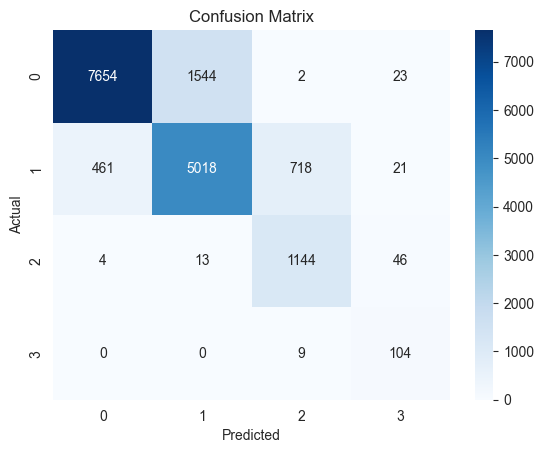

In [12]:
#Avaliação da rede para classificação
clf_trainer.evaluate(X_clf_test_t, y_clf_test_t)
y_pred_clf = clf_trainer.predict(X_clf_test_t)
print("Predicted classes:", torch.unique(y_pred_clf, return_counts=True))
print("Actual classes:", torch.unique(y_clf_test_t))

cm = confusion_matrix(y_clf_test_t.numpy(), y_pred_clf.numpy())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
#Regressão com Neural Network
X_reg_train = analizer_reg.data_train
y_reg_train = analizer_reg.labels_train

# Convert to tensors with proper shapes
X_reg_train_t = torch.tensor(X_reg_train.values, dtype=torch.float32)
y_reg_train_t = torch.tensor(y_reg_train.values, dtype=torch.float32).reshape(-1, 1)

X_reg_test_t = torch.tensor(analizer_reg.data_test.values, dtype=torch.float32)
y_reg_test_t = torch.tensor(analizer_reg.labels_test.values, dtype=torch.float32).reshape(-1, 1)

# Model
reg_model = BaseNeuralNetwork(input_dim=X_reg_train_t.shape[1], output_dim=1, task_type='regression')
reg_trainer = NeuralNetworkTrainer(reg_model, task='regression')  # No class weights for regression
# Train
reg_trainer.train(X_reg_train_t, y_reg_train_t, epochs=100)

# Evaluation
with torch.no_grad():
    predictions = reg_model(X_reg_test_t)

    # No need to squeeze since both are now [batch_size, 1]
    mse = torch.mean((predictions - y_reg_test_t) ** 2).item()
    mae = torch.mean(torch.abs(predictions - y_reg_test_t)).item()

    # Calculate R² score
    y_mean = torch.mean(y_reg_test_t)
    ss_tot = torch.sum((y_reg_test_t - y_mean) ** 2)
    ss_res = torch.sum((y_reg_test_t - predictions) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Optional: Plot some predictions vs actual
    print("\nSample predictions vs actual values:")
    for i in range(min(10, len(predictions))):
        print(f"Sample {i}: Actual = {y_reg_test_t[i].item():.4f}, Predicted = {predictions[i].item():.4f}")


torch.save(reg_model.state_dict(), model_output_dir+"NeuralNetworkRegressor.pth")
print(f"Model state dictionary saved to {model_output_dir}/NeuralNetworkRegressor.pth")

Epoch 0 - Loss: 10.7162
Epoch 10 - Loss: 7.2931
Epoch 20 - Loss: 18.2231
Epoch 30 - Loss: 32.8914
Epoch 40 - Loss: 11.8047
Epoch 50 - Loss: 79.4230
Epoch 60 - Loss: 9.0305
Epoch 70 - Loss: 9.5308
Epoch 80 - Loss: 3.8785
Epoch 90 - Loss: 11.2926
Mean Squared Error: 178.2608
Mean Absolute Error: 3.1967
R² Score: -0.0426

Sample predictions vs actual values:
Sample 0: Actual = 29.5000, Predicted = 29.0954
Sample 1: Actual = 14.5000, Predicted = 14.2497
Sample 2: Actual = 6.5000, Predicted = 4.3330
Sample 3: Actual = 13.5000, Predicted = 13.4497
Sample 4: Actual = 9.5000, Predicted = 8.4785
Sample 5: Actual = 7.0000, Predicted = 3.8191
Sample 6: Actual = 6.0000, Predicted = 8.4750
Sample 7: Actual = 8.0000, Predicted = 8.6381
Sample 8: Actual = 19.0000, Predicted = 15.0602
Sample 9: Actual = 7.0000, Predicted = 6.0385


# K-Prototypes (Clustering por partição)

In [16]:
print("\n" + "=" * 40)
print("--- Clustering com K-Prototypes ---")

# Placeholder para os índices das colunas categóricas.
# VOCÊ DEVE SUBSTITUIR ISSO PELOS ÍNDICES REAIS DAS SUAS COLUNAS CATEGÓRICAS NO analizer_reg.data_train
try:
    # Tenta inferir de analizer_reg.data_train se for um DataFrame e tiver dtypes mistos
    # Isso é uma tentativa e pode não funcionar para todos os cenários.
    if hasattr(analizer_reg, 'data_train') and isinstance(analizer_reg.data_train, pd.DataFrame):
        categorical_indices_kproto = [i for i, dtype in enumerate(analizer_reg.data_train.dtypes) if dtype == 'object' or pd.api.types.is_categorical_dtype(dtype)]
        if not categorical_indices_kproto and analizer_reg.data_train.empty:
             print("Aviso: analizer_reg.data_train está vazio ou não é um DataFrame para inferir índices categóricos.")
        elif not categorical_indices_kproto:
            print("Aviso: Nenhuma coluna 'object' ou 'categorical' encontrada. K-Prototypes pode não ser adequado se não houver colunas categóricas.")
    else:
        print("Aviso: analizer_reg.data_train não é um Pandas DataFrame. Por favor, defina 'categorical_indices_kproto' manualmente.")
        categorical_indices_kproto = [] # Placeholder vazio, precisa ser preenchido pelo usuário
except AttributeError:
    print("Erro: 'analizer_reg' ou 'data_train' não encontrados. Por favor, certifique-se de que 'analizer_reg' está inicializado.")
    categorical_indices_kproto = [] # Default para evitar erro, mas o código falhará sem índices corretos


if not categorical_indices_kproto:
    print("\nERRO CRÍTICO: Índices das colunas categóricas para K-Prototypes NÃO definidos.")
    print("Por favor, garanta que 'categorical_indices_kproto' contém os índices corretos das suas features categóricas.")
    print("Não é possível prosseguir com K-Prototypes sem essa informação.")
else:
    print(f"Índices categóricos identificados para K-Prototypes: {categorical_indices_kproto}")

    # Valores para n_clusters. Pode ser ajustado conforme a análise exploratória de dados.
    n_clusters_values_kproto = [3, 4, 5] # Exemplo de valores para número de clusters
    best_cost_kproto = float('inf')
    best_params_kproto = None
    all_kproto_results = {} # Armazena todos os resultados

    for n_cl in n_clusters_values_kproto:
        current_params = {'n_clusters': n_cl}
        print(f"\nAvaliando K-Prototypes com n_clusters = {n_cl}...")

        try:
            # Instantiate KPrototypes model
            # random_state é importante para reprodutibilidade da inicialização
            kproto_model = KPrototypesModel(
                n_clusters=n_cl,
                categorical_indices=categorical_indices_kproto,
                n_init=10, # Rodar 10 vezes com diferentes sementes e pegar o melhor resultado
                random_state=42
            )

            # Fit the model on the training data
            # Para clustering, o 'y' é ignorado na função fit
            kproto_model.fit(analizer_reg.data_train)

            # Evaluate the model (get the cost)
            results_kproto = kproto_model.evaluate()
            all_kproto_results[n_cl] = results_kproto

            current_cost = results_kproto.get('cost')
            print(f"Parâmetros: n_clusters={n_cl}")
            if current_cost is not None:
                print(f"Custo (Distorção): {current_cost:.4f}")

                # Logic to select the best model based on the lowest cost
                if current_cost < best_cost_kproto:
                    best_cost_kproto = current_cost
                    best_params_kproto = current_params
                    print(f" -> Novo melhor conjunto de parâmetros para K-Prototypes encontrado: {best_params_kproto} (Custo={best_cost_kproto:.4f})")

        except Exception as e:
            print(f"Ocorreu um erro durante a avaliação do K-Prototypes para n_clusters {n_cl}: {e}")

    # --- Treinar e Salvar o Melhor Modelo de Clustering K-Prototypes ---
    if best_params_kproto is not None:
        print("-" * 30)
        print(f"Melhores parâmetros encontrados para K-Prototypes: {best_params_kproto}")
        print(f"Melhor Custo: {best_cost_kproto:.4f}")

        # 1. Re-treinar o modelo final com os melhores parâmetros em TODOS os dados de TREINO
        print(f"Re-treinando o modelo K-Prototypes com {best_params_kproto['n_clusters']} clusters no conjunto de treino completo...")
        final_best_kproto_model = KPrototypesModel(
            n_clusters=best_params_kproto['n_clusters'],
            categorical_indices=categorical_indices_kproto,
            n_init=10, # Manter o n_init usado na seleção
            random_state=42
        )
        final_best_kproto_model.fit(analizer_reg.data_train)

        # 2. Salvar o melhor modelo de CLUSTERING K-Prototypes
        model_filename_kproto = f"KPrototypesClustering_nClusters.pkl"
        model_full_path_kproto = model_output_dir + model_filename_kproto

        print(f"Salvando o melhor modelo K-Prototypes em: {model_full_path_kproto.resolve()}")
        # Assumindo que a classe KPrototypes herda de BaseModel e tem um método serialize
        final_best_kproto_model.serialize(str(model_full_path_kproto)) # Serialize espera string ou PathLike
        print(f"Melhor modelo K-Prototypes salvo com sucesso!")
        print("-" * 30)

        # 3. Plotar os resultados do clustering
        print("\n" + "=" * 40)
        print("--- Visualizando Clusters K-Prototypes ---")
        try:
            final_best_kproto_model.plot_clusters(analizer_reg.data_train, title="K-Prototypes Clustering Resultados")
            print("Visualização dos clusters K-Prototypes concluída.")
        except RuntimeError as e:
            print(f"Não foi possível plotar os clusters. Erro: {e}")
        except Exception as e:
            print(f"Ocorreu um erro inesperado durante a plotagem dos clusters: {e}")

    else:
        print("-" * 30)
        print("Nenhum modelo K-Prototypes foi avaliado e selecionado com sucesso.")
        print("-" * 30)

print("\nScript execution finished.")


--- Clustering com K-Prototypes ---
Aviso: Nenhuma coluna 'object' ou 'categorical' encontrada. K-Prototypes pode não ser adequado se não houver colunas categóricas.

ERRO CRÍTICO: Índices das colunas categóricas para K-Prototypes NÃO definidos.
Por favor, garanta que 'categorical_indices_kproto' contém os índices corretos das suas features categóricas.
Não é possível prosseguir com K-Prototypes sem essa informação.

Script execution finished.


C:\Users\usoda\AppData\Local\Temp\ipykernel_6708\1983345044.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categorical_indices_kproto = [i for i, dtype in enumerate(analizer_reg.data_train.dtypes) if dtype == 'object' or pd.api.types.is_categorical_dtype(dtype)]


# GDBSCAN (Clustering por densidade)

In [14]:
print("\n" + "=" * 40)
print("--- Clustering com GDBSCANMixed ---")

# Valores de exemplo para hiperparâmetros
# eps é o raio da vizinhança, min_samples é o número mínimo de pontos na vizinhança
# A escolha de eps é crucial e geralmente requer conhecimento do domínio ou análise de k-distância.
eps_values_gdbscan = [0.1, 0.5, 1.0] # Exemplo: valores de raio
min_samples_values_gdbscan = [5, 10, 15] # Exemplo: valores de min_samples

# Para GDBSCAN, a "melhor" configuração não é determinada por um único score numérico como o custo do K-Prototypes.
# É mais sobre a interpretabilidade e a estrutura dos clusters.
# Podemos rastrear o número de clusters encontrados ou a porcentagem de ruído.
best_model_gdbscan = None
best_num_clusters = -1
best_noise_percentage = float('inf')
best_gdbscan_params = None
all_gdbscan_results = {}

# Suponha que analizer_reg.labels_train possa ser um 'y_test' para avaliação externa (se houver)
# Se não houver ground truth, y_test_for_eval deve ser None
y_test_for_eval = getattr(analizer_reg, 'labels_train', None) # Se houver labels de treino que sirvam como ground truth

for eps_val in eps_values_gdbscan:
    for min_s_val in min_samples_values_gdbscan:
        current_params = {'eps': eps_val, 'min_samples': min_s_val}
        print(f"\nAvaliando GDBSCANMixed com eps = {eps_val}, min_samples = {min_s_val}...")

        try:
            gdbscan_model = GDBSCANMixed(
                eps=eps_val,
                min_samples=min_s_val,
                distance_metric='gower' # Usando a distância de Gower embutida
            )

            # Fit the model on the training data
            gdbscan_model.fit(analizer_reg.data_train)

            # Evaluate the model (ARI, NMI if y_test_for_eval is available)
            # A classe GDBSCANMixed.evaluate aceita y_test.
            results_gdbscan = gdbscan_model.evaluate(X_test=analizer_reg.data_train, y_test=y_test_for_eval)
            all_gdbscan_results[(eps_val, min_s_val)] = results_gdbscan

            print(f"Parâmetros: eps={eps_val}, min_samples={min_s_val}")
            
            # Contar o número de clusters e pontos de ruído
            unique_labels = np.unique(gdbscan_model.labels)
            num_clusters = len(unique_labels[unique_labels != -1])
            noise_points = np.sum(gdbscan_model.labels == -1)
            total_points = len(gdbscan_model.labels)
            noise_percentage = (noise_points / total_points) * 100 if total_points > 0 else 0

            print(f"Número de Clusters Encontrados: {num_clusters}")
            print(f"Número de Pontos de Ruído: {noise_points} ({noise_percentage:.2f}%)")

            if 'adjusted_rand_score' in results_gdbscan:
                print(f"Adjusted Rand Score: {results_gdbscan['adjusted_rand_score']:.4f}")
            if 'normalized_mutual_info_score' in results_gdbscan:
                print(f"Normalized Mutual Information Score: {results_gdbscan['normalized_mutual_info_score']:.4f}")
            
            # Lógica de seleção do "melhor" modelo:
            # Para GDBSCAN, pode ser a combinação que gera um número razoável de clusters
            # com uma quantidade aceitável de ruído, ou o maior ARI/NMI se ground truth estiver disponível.
            # Aqui, vamos priorizar o modelo com o maior ARI se disponível, ou menor ruído se não.
            
            current_ari = results_gdbscan.get('adjusted_rand_score', -1.0) # Assume -1 se não calculável
            
            # Lógica simplificada: Se temos ARI, priorizamos o maior ARI.
            # Caso contrário, tentamos balancear número de clusters e ruído.
            # Este é um exemplo, a lógica de seleção de "melhor" para GDBSCAN é complexa.
            if y_test_for_eval is not None and current_ari > best_num_clusters: # Reutilizando a variável para armazenar o melhor ARI
                best_num_clusters = current_ari # Store the ARI as the "best score"
                best_gdbscan_params = current_params
                best_model_gdbscan = gdbscan_model # Store the fitted model temporarily
                print(f" -> Novo melhor conjunto de parâmetros para GDBSCANMixed encontrado (baseado em ARI): {best_gdbscan_params} (ARI={best_num_clusters:.4f})")
            elif y_test_for_eval is None: # Se não houver ground truth, heuristicamente.
                # Heurística: menos ruído e mais de 1 cluster (ou um número 'razoável').
                # Isso é muito simplificado e pode ser ajustado.
                if noise_percentage < best_noise_percentage and num_clusters > 1:
                    best_noise_percentage = noise_percentage
                    best_gdbscan_params = current_params
                    best_model_gdbscan = gdbscan_model
                    print(f" -> Novo melhor conjunto de parâmetros para GDBSCANMixed encontrado (baseado em menor ruído): {best_gdbscan_params} (Ruído={best_noise_percentage:.2f}%, Clusters={num_clusters})")

        except Exception as e:
            print(f"Ocorreu um erro durante a avaliação do GDBSCANMixed para parâmetros {current_params}: {e}")

# --- Treinar e Salvar o Melhor Modelo de Clustering GDBSCANMixed ---
if best_gdbscan_params is not None:
    print("-" * 30)
    print(f"Melhores parâmetros encontrados para GDBSCANMixed após avaliação: {best_gdbscan_params}")
    # Se y_test_for_eval existe, printa o melhor ARI, senão, a melhor % de ruído
    if y_test_for_eval is not None:
        print(f"Melhor Adjusted Rand Score: {best_num_clusters:.4f}")
    else:
        print(f"Menor Porcentagem de Ruído: {best_noise_percentage:.2f}%")


    # O best_model_gdbscan já está treinado com os melhores parâmetros.
    # Apenas o salvamos e visualizamos.
    print(f"Salvando o melhor modelo GDBSCANMixed...")

    eps_val = best_gdbscan_params['eps']
    min_s_val = best_gdbscan_params['min_samples']
    
    # Criar um nome de arquivo descritivo
    model_filename_gdbscan = f"GDBSCANMixed_eps{eps_val:.2f}_minS{min_s_val}"
    if y_test_for_eval is not None:
        model_filename_gdbscan += f"_ari{best_num_clusters:.2f}"
    else:
        model_filename_gdbscan += f"_noise{best_noise_percentage:.2f}%.pkl" # Nomeando com % de ruído
    model_full_path_gdbscan = model_output_dir + (model_filename_gdbscan.replace('.', '_') + ".pkl") # Substituir '.' para nome de arquivo
    
    print(f"Salvando o melhor modelo GDBSCANMixed em: {model_full_path_gdbscan.resolve()}")
    
    # GDBSCANMixed não herda de BaseModel, então precisa de uma função de serialização manual.
    # Adicionando um método serialize à classe GDBSCANMixed
    import pickle
    try:
        with open(model_full_path_gdbscan, 'wb') as f:
            pickle.dump(best_model_gdbscan, f)
        print(f"Melhor modelo GDBSCANMixed salvo com sucesso!")
    except Exception as e:
        print(f"Erro ao salvar o modelo GDBSCANMixed: {e}")
    
    print("-" * 30)

    # 3. Plotar os resultados do clustering
    print("\n" + "=" * 40)
    print("--- Visualizando Clusters GDBSCANMixed ---")
    try:
        # Passamos o analizer_reg.data_train pois o plot_clusters usa os dados que foram 'fitted'
        best_model_gdbscan.plot_clusters(analizer_reg.data_train, title="GDBSCANMixed Clustering Resultados")
        print("Visualização dos clusters GDBSCANMixed concluída.")
    except RuntimeError as e:
        print(f"Não foi possível plotar os clusters. Erro: {e}")
    except Exception as e:
        print(f"Ocorreu um erro inesperado durante a plotagem dos clusters: {e}")

else:
    print("-" * 30)
    print("Nenhum modelo GDBSCANMixed foi avaliado e selecionado com sucesso.")
    print("-" * 30)

print("\nScript execution finished.")


--- Clustering com GDBSCANMixed ---

Avaliando GDBSCANMixed com eps = 0.1, min_samples = 5...
Ocorreu um erro durante a avaliação do GDBSCANMixed para parâmetros {'eps': 0.1, 'min_samples': 5}: Unable to allocate 50.9 GiB for an array with shape (82689, 82689) and data type float64

Avaliando GDBSCANMixed com eps = 0.1, min_samples = 10...
Ocorreu um erro durante a avaliação do GDBSCANMixed para parâmetros {'eps': 0.1, 'min_samples': 10}: Unable to allocate 50.9 GiB for an array with shape (82689, 82689) and data type float64

Avaliando GDBSCANMixed com eps = 0.1, min_samples = 15...
Ocorreu um erro durante a avaliação do GDBSCANMixed para parâmetros {'eps': 0.1, 'min_samples': 15}: Unable to allocate 50.9 GiB for an array with shape (82689, 82689) and data type float64

Avaliando GDBSCANMixed com eps = 0.5, min_samples = 5...
Ocorreu um erro durante a avaliação do GDBSCANMixed para parâmetros {'eps': 0.5, 'min_samples': 5}: Unable to allocate 50.9 GiB for an array with shape (82689, 